# Region Setup

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from study_location import bootstrap
session = bootstrap()
location_root = session.location_root
repo_root = session.repo_root
# build domains, collect static inputs, and show QA plots.
import sfincs_runs.build_base.region_notebook as region

pd.set_option("display.max_colwidth", 140)

## Imports and Runtime


In [2]:
runtime = region.load_runtime(location_root)

pd.Series(
    {
        "location": runtime.config["project"]["place_name"],
        "selected_sfincs_domain_ids": runtime.sfincs_config["sfincs_domain_set"]["include_domain_ids"],
        "source_record_syntax": 'location_root / "data" / "sources" / "..."',
        "static_record_syntax": 'location_root / "data" / "static" / "..."',
    },
    name="region_setup_parameters",
)


location                                                 Austin, TX, USA
selected_sfincs_domain_ids                                  [austin_p5u]
source_record_syntax          location_root / "data" / "sources" / "..."
static_record_syntax           location_root / "data" / "static" / "..."
Name: region_setup_parameters, dtype: object

## SMART-DS AOI and Evaluation Footprint

study_area                          locations/austin/data/static/aoi/study_area.geojson
evaluation_footprint      locations/austin/data/static/aoi/evaluation_footprint.geojson
source_format                                                        smart_ds_buscoords
subregion_count                                                                       6
bounds                                   (-98.182095, 30.025467, -97.375456, 30.637603)
minimum_flood_coverage                                                             True
Name: smart_ds_aoi, dtype: object

selected_sfincs_domain_ids                                                           austin_p5u
sfincs_coverage                                   locations/austin/data/static/aoi/bbox.geojson
wflow_huc_watersheds          locations/austin/data/static/aoi/wflow_nhdplus_watersheds.geojson
wflow_collection_boundary      locations/austin/data/static/aoi/wflow_collection_region.geojson
wbd_service                    https://hydro.nationalmap.gov/arcgis/rest/services/wbd/MapServer
huc_level                                                                                     8
huc_kind                                                                                 single
Name: selected_inland_region_domains, dtype: str

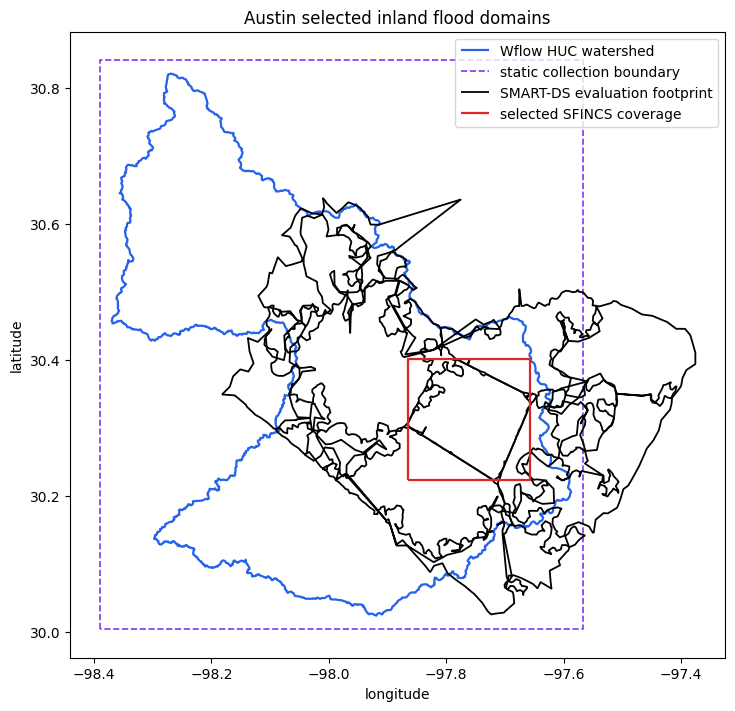

In [3]:
domains = region.build_domains(runtime)

display(domains.footprint.summary)
display(domains.summary)
region.plot_domains(runtime, domains)
plt.show()


## SFINCS and Wflow Terrain/Landcover Inputs

In [4]:
static_data = region.collect_static(runtime)  # collect_required_inland_static_data(runtime)

display(static_data.wflow_summary)
static_data.sfincs_summary


dem                            /home/grahamhults/projects/Flood-RM/locations/austin/data/wflow/static/processed/dem_wflow_coarse.tif
landcover                /home/grahamhults/projects/Flood-RM/locations/austin/data/wflow/static/processed/landcover_wflow_coarse.tif
dem_pixels                                                                                                                    851865
landcover_pixels                                                                                                              851865
ssurgo_polygons                                                                                                                62427
ssurgo_attribute_rows                                                                                                           3549
soil_mukeys                                                                                                                      880
hsg                                       /home/grahamhults/projects/

dem                            /home/grahamhults/projects/Flood-RM/locations/austin/data/static/processed/dem_region_setup.tif
landcover                /home/grahamhults/projects/Flood-RM/locations/austin/data/static/processed/landcover_region_setup.tif
dem_pixels                                                                                                             4336032
landcover_pixels                                                                                                       4336032
ssurgo_polygons                                                                                                          17422
ssurgo_attribute_rows                                                                                                     1281
soil_mukeys                                                                                                                342
hsg                                      /home/grahamhults/projects/Flood-RM/locations/austin/data/static/soils

## Region Setup QA


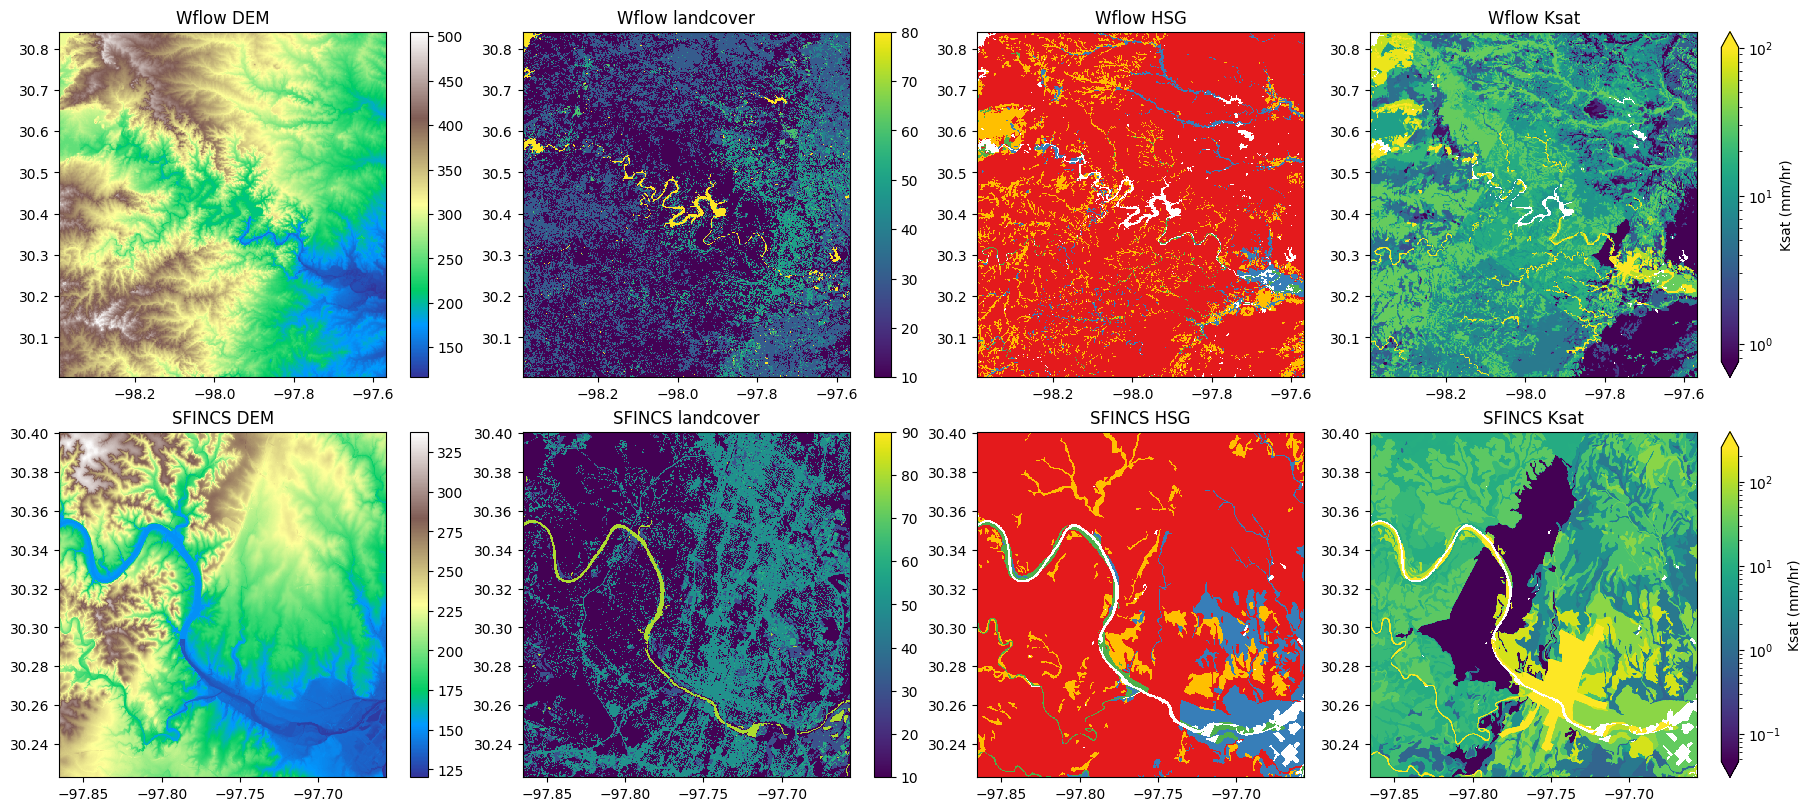

In [5]:
static_plot = region.plot_static(runtime)
if isinstance(static_plot, pd.DataFrame):
    display(static_plot)
else:
    plt.show()
